In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
df = pd.read_csv('traffic_accidents.csv')
df.head()

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5.0,0.0,0.0,5.0,0.0,0.0,19,4,8
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,14,7,8


In [7]:
df.describe()

,num_units,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
count,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000
mean,2.063300,0.382717,0.001859,0.038102,0.221241,0.121516,2.244002,13.373047,4.144024,6.771822
std,0.396012,0.799720,0.047502,0.233964,0.614960,0.450865,1.241175,5.603830,1.966864,3.427593
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,9.000000,2.000000,4.000000
50%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,14.000000,4.000000,7.000000
75%,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.000000,17.000000,6.000000,10.000000
max,11.000000,21.000000,3.000000,7.000000,21.000000,15.000000,49.000000,23.000000,7.000000,12.000000


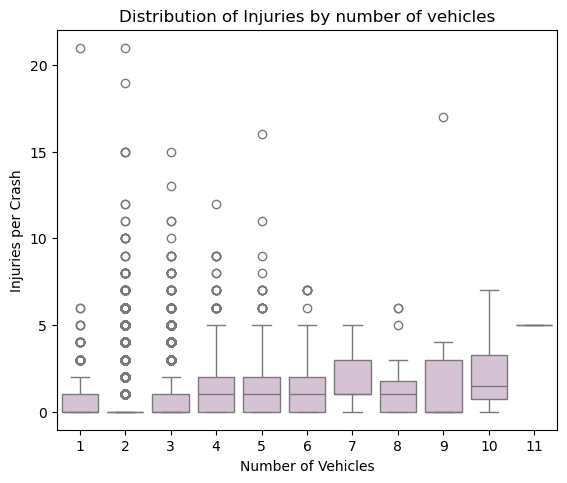

In [365]:
# Figure 0 : boxplot  - injuries by num of cars

fig = plt.figure(figsize=(5,4))
ax = fig.add_axes([0,0,1,1,])
sns.boxplot(data=df, x='num_units', y='injuries_total', color='#D8BFD8')
ax.set_title("Distribution of Injuries by number of vehicles")
ax.set_xlabel("Number of Vehicles")
ax.set_ylabel("Injuries per Crash")
plt.show()

In [367]:
device = df.groupby('traffic_control_device')['traffic_control_device'].count().reset_index(name='cnt')
device

,traffic_control_device,cnt
0,BICYCLE CROSSING SIGN,11
1,DELINEATORS,17
2,FLASHING CONTROL SIGNAL,150
3,LANE USE MARKING,153
4,NO CONTROLS,29508
5,NO PASSING,12
6,OTHER,670
7,OTHER RAILROAD CROSSING,23
8,OTHER REG. SIGN,181
9,OTHER WARNING SIGN,95


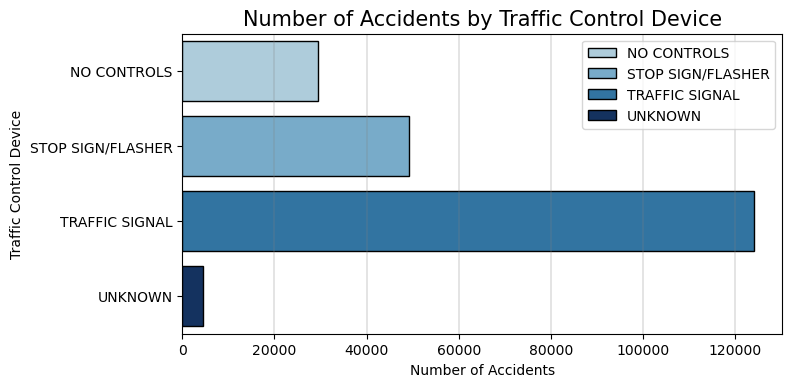

In [369]:
# Figure 1: (1) barplot  - top 4 traffic_control_device

## Filter
device = device[ (device['traffic_control_device']=='NO CONTROLS') | (device['traffic_control_device']=='TRAFFIC SIGNAL') | (device['traffic_control_device']=='STOP SIGN/FLASHER') | (device['traffic_control_device']=='UNKNOWN')]
c = ['#a6cee3','#6baed6','#1f78b4','#08306b']

fig = plt.figure(figsize=(6,3))
ax = fig.add_axes([0,0,1,1])

sns.barplot(data=device, y='traffic_control_device', x='cnt', hue='traffic_control_device', palette=c, edgecolor='black', legend=True)
ax.set_title('Number of Accidents by Traffic Control Device', fontsize=15)
ax.set_xlabel('Number of Accidents')
ax.set_ylabel('Traffic Control Device')
plt.legend()
plt.grid(axis='x', color = 'gray', linewidth = 0.3)
plt.show()

In [371]:
weather =df.groupby('weather_condition')['weather_condition'].count().reset_index(name='cnt')
weather

,weather_condition,cnt
0,"BLOWING SAND, SOIL, DIRT",1
1,BLOWING SNOW,127
2,CLEAR,164700
3,CLOUDY/OVERCAST,7533
4,FOG/SMOKE/HAZE,360
5,FREEZING RAIN/DRIZZLE,510
6,OTHER,627
7,RAIN,21703
8,SEVERE CROSS WIND GATE,32
9,SLEET/HAIL,308


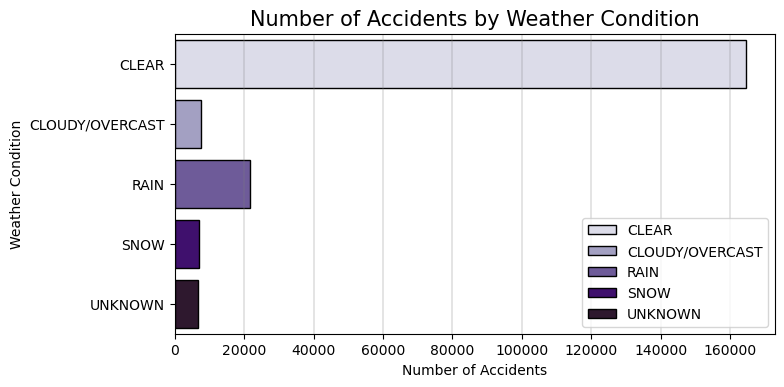

In [373]:
# Figure 1: (2) barplot  - top 5 weather conditions

# Filter by the five most occurring weather conditions 
weather = weather[ (weather['weather_condition']=='CLEAR') | (weather['weather_condition']=='CLOUDY/OVERCAST') | (weather['weather_condition']=='RAIN') | (weather['weather_condition']=='SNOW') | (weather['weather_condition']=='UNKNOWN')]


fig = plt.figure(figsize=(6,3))
ax = fig.add_axes([0,0,1,1])
c1 = ['#dadaeb', '#9e9ac8', '#6a51a3', '#3f007d','#311432']

sns.barplot(data=weather, y='weather_condition', x='cnt', hue='weather_condition', palette=c1, edgecolor='black', legend=True)
ax.set_title('Number of Accidents by Weather Condition', fontsize=15)
ax.set_xlabel('Number of Accidents')
ax.set_ylabel('Weather Condition')
plt.legend()
plt.grid(axis='x', color = 'gray', linewidth = 0.3)
plt.show()

In [375]:
lighting = df.groupby('lighting_condition')['lighting_condition'].count().reset_index(name='cnt')
lighting

,lighting_condition,cnt
0,DARKNESS,7436
1,"DARKNESS, LIGHTED ROAD",53378
2,DAWN,3724
3,DAYLIGHT,134109
4,DUSK,6323
5,UNKNOWN,4336


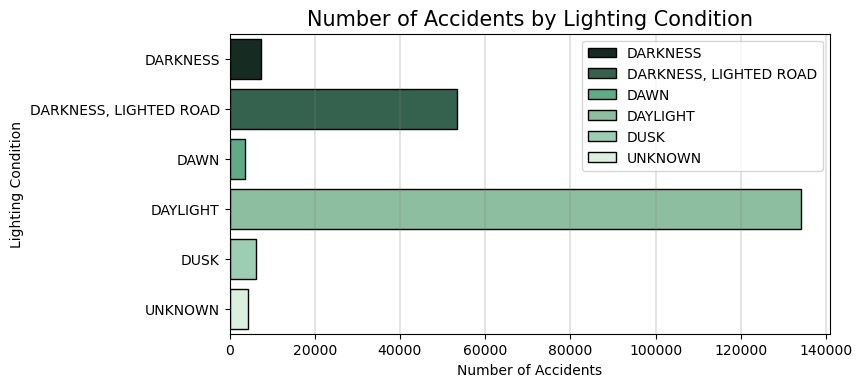

In [377]:
# Figure 1: (3) barplot  - lighting conditions

fig = plt.figure(figsize=(6,3))
ax = fig.add_axes([0,0,1,1])
c2 = ['#123024', '#2D6A4F', '#52B788', '#85C69D', '#95D5B2', '#D8F3DC']
      
sns.barplot(data=lighting, y='lighting_condition', x='cnt', hue='lighting_condition', palette=c2, edgecolor='black', legend=True)
ax.set_title('Number of Accidents by Lighting Condition', fontsize=15)
ax.set_xlabel('Number of Accidents')
ax.set_ylabel('Lighting Condition')
plt.legend()
plt.grid(axis='x', color = 'gray', linewidth = 0.3)
plt.show()

In [379]:
trafficway = df.groupby('trafficway_type')['trafficway_type'].count().reset_index(name='cnt')
trafficway

,trafficway_type,cnt
0,ALLEY,741
1,CENTER TURN LANE,2862
2,DIVIDED - W/MEDIAN (NOT RAISED),34221
3,DIVIDED - W/MEDIAN BARRIER,10720
4,DRIVEWAY,143
5,"FIVE POINT, OR MORE",1119
6,FOUR WAY,49057
7,L-INTERSECTION,127
8,NOT DIVIDED,77753
9,NOT REPORTED,581


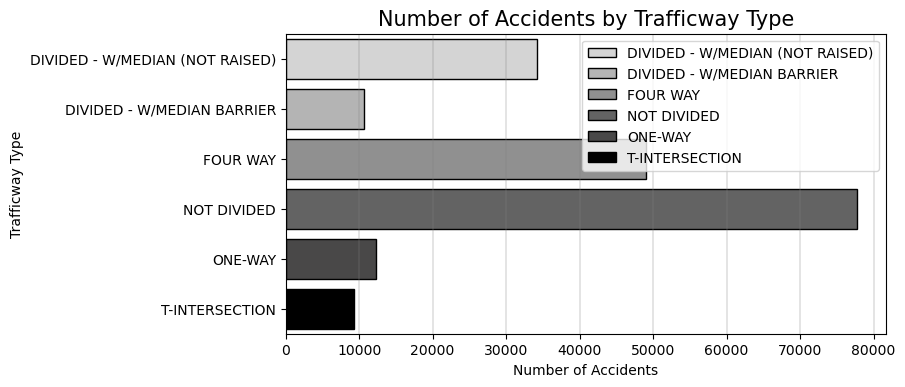

In [397]:
# Figure 1: (4) barplot  - trafficway type
# Filter Top 6

trafficway = trafficway[ (trafficway['trafficway_type']=='DIVIDED - W/MEDIAN (NOT RAISED)') | (trafficway['trafficway_type']=='DIVIDED - W/MEDIAN BARRIER') | (trafficway['trafficway_type']=='FOUR WAY') | (trafficway['trafficway_type']=='NOT DIVIDED') | (trafficway['trafficway_type']=='T-INTERSECTION') | (trafficway['trafficway_type']=='ONE-WAY')  ]


fig = plt.figure(figsize=(6,3))
ax = fig.add_axes([0,0,1,1])
c3 = ['#D4D4D4', '#B4B4B4', '#909090', '#636363', '#494848', 'black']
      
sns.barplot(data=trafficway, y='trafficway_type', x='cnt', hue='trafficway_type', palette=c3, edgecolor='black', legend=True)
ax.set_title('Number of Accidents by Trafficway Type', fontsize=15)
ax.set_xlabel('Number of Accidents')
ax.set_ylabel('Trafficway Type')
plt.legend()
plt.grid(axis='x', color = 'gray', linewidth = 0.3)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_10588\1875369960.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(['','','',''])
C:\Users\HP\AppData\Local\Temp\ipykernel_10588\1875369960.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(['','','','',''])
C:\Users\HP\AppData\Local\Temp\ipykernel_10588\1875369960.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels(['','','','','',''])
C:\Users\HP\AppData\Local\Temp\ipykernel_10588\1875369960.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_yticklabels(['','','','','',''])


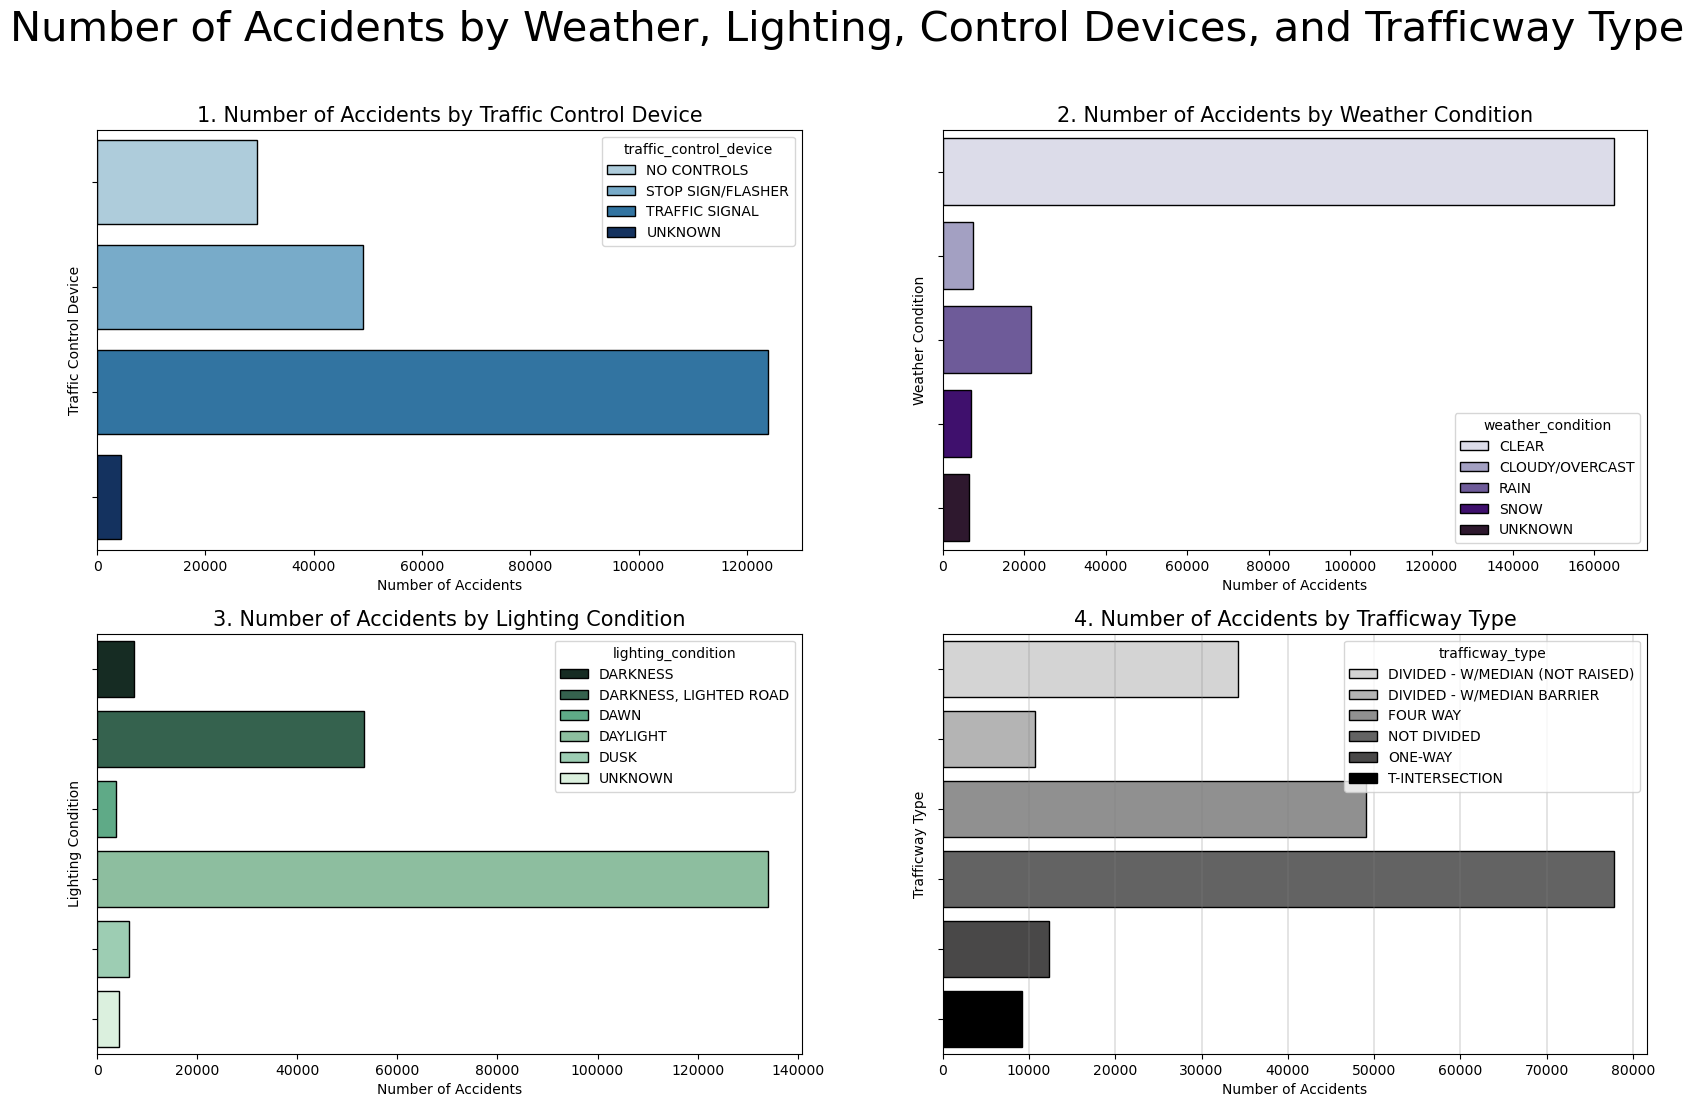

In [383]:
## Figure 1
## combine the 4 subplots
fig = fig = plt.figure(figsize=(20,12))
ax1 = fig.add_subplot(221)
sns.barplot(data=device, y='traffic_control_device', x='cnt', hue='traffic_control_device', palette=c, edgecolor='black', legend=True)
ax1.set_title('1. Number of Accidents by Traffic Control Device', fontsize=15)
ax1.set_xlabel('Number of Accidents')
ax1.set_ylabel('Traffic Control Device')
ax1.set_yticklabels(['','','',''])


ax2 = fig.add_subplot(222)
sns.barplot(data=weather, y='weather_condition', x='cnt', hue='weather_condition', palette=c1, edgecolor='black', legend=True)
ax2.set_title('2. Number of Accidents by Weather Condition', fontsize=15)
ax2.set_xlabel('Number of Accidents')
ax2.set_ylabel('Weather Condition')
ax2.set_yticklabels(['','','','',''])

ax3 = fig.add_subplot(223)
sns.barplot(data=lighting, y='lighting_condition', x='cnt', hue='lighting_condition', palette=c2, edgecolor='black', legend=True)
ax3.set_title('3. Number of Accidents by Lighting Condition', fontsize=15)
ax3.set_xlabel('Number of Accidents')
ax3.set_ylabel('Lighting Condition')
ax3.set_yticklabels(['','','','','',''])

ax4 = fig.add_subplot(224)
sns.barplot(data=trafficway, y='trafficway_type', x='cnt', hue='trafficway_type', palette=c3, edgecolor='black', legend=True)
ax4.set_title('4. Number of Accidents by Trafficway Type', fontsize=15)
ax4.set_xlabel('Number of Accidents')
ax4.set_ylabel('Trafficway Type')
ax4.set_yticklabels(['','','','','',''])

plt.suptitle('Number of Accidents by Weather, Lighting, Control Devices, and Trafficway Type', fontsize=30)

plt.grid(axis='x', color = 'gray', linewidth = 0.3)
plt.show()

In [14]:
max = df.groupby('num_units')['injuries_total'].max().reset_index(name='MAX')
total_accidents = df.groupby('num_units')['injuries_total'].sum().reset_index(name='cnt')

data1 = pd.merge(max, total_accidents, how='left', on='num_units')
data1

,num_units,MAX,cnt
0,1,21.0,1692.0
1,2,21.0,65720.0
2,3,15.0,9570.0
3,4,12.0,2153.0
4,5,16.0,659.0
5,6,7.0,181.0
6,7,5.0,58.0
7,8,6.0,32.0
8,9,17.0,25.0
9,10,7.0,10.0


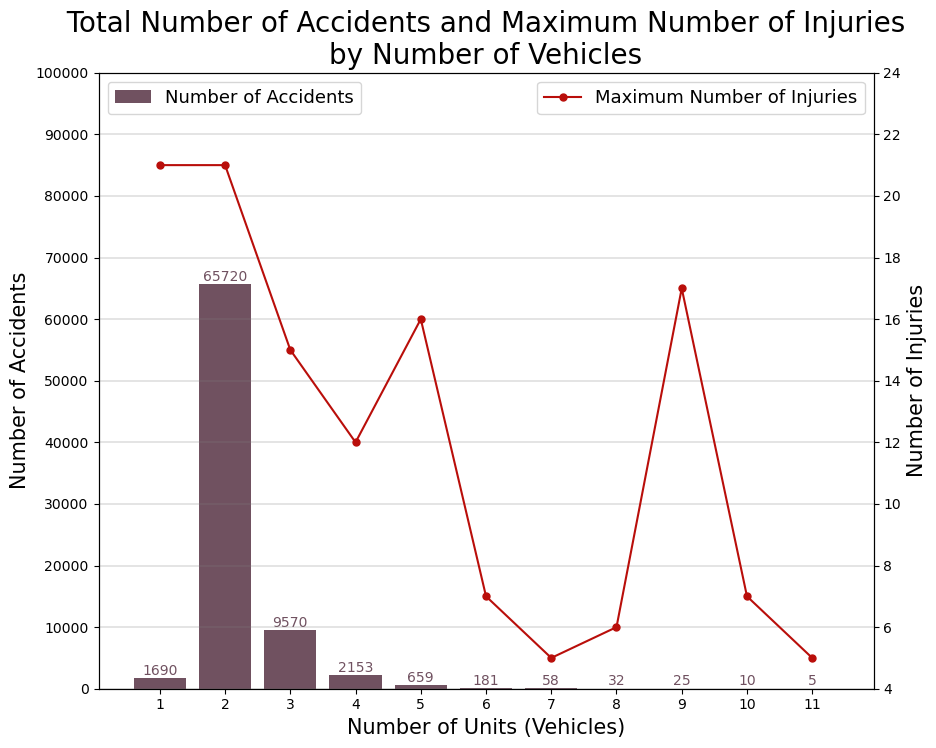

In [16]:
# Figure 2 : barplot  - num of accidents & max num of injuries by num of units

fig = plt.figure(figsize=(10,8))

ax1 = plt.subplot(111)
ax1.bar(data1['num_units'], data1['cnt'], color='#705160', label='Number of Accidents')
ax1.set_xlabel('Number of Units (Vehicles)', fontsize=15)
ax1.set_ylabel('Number of Accidents', fontsize=15)
ax1.tick_params(axis = 'y')
ax1.set_xticks(np.arange(1,12,1))
ax1.set_yticks(np.arange(0,110000,10000))
ax1.legend(loc='upper left', fontsize = 13)

## To write the exact number of crashes 
ax1.text(1, 1690, '1690', ha='center', va='bottom', color='#705160')
ax1.text(2, 65720, '65720', ha='center', va='bottom', color='#705160')
ax1.text(3, 9570, '9570', ha='center', va='bottom', color='#705160')
ax1.text(4, 2153, '2153', ha='center', va='bottom', color='#705160')
ax1.text(5, 659, '659', ha='center', va='bottom', color='#705160')
ax1.text(6, 200, '181', ha='center', va='bottom', color='#705160')
ax1.text(7, 100, '58', ha='center', va='bottom', color='#705160')
ax1.text(8, 100, '32', ha='center', va='bottom', color='#705160')
ax1.text(9, 100, '25', ha='center', va='bottom', color='#705160')
ax1.text(10, 100, '10', ha='center', va='bottom', color='#705160')
ax1.text(11, 100, '5', ha='center', va='bottom', color='#705160')


ax2 = ax1.twinx()
ax2.plot(data1['num_units'],data1['MAX'], color = '#B90E0A', marker='o', markersize=5, label ='Maximum Number of Injuries')
ax2.set_ylabel('Number of Injuries', fontsize=15)
ax2.tick_params(axis = 'y')
ax2.set_yticks(np.arange(4,25,2))
ax2.legend(loc='upper right', fontsize = 13)


plt.grid(color = 'gray', linewidth = 0.3)
plt.title(' Total Number of Accidents and Maximum Number of Injuries \nby Number of Vehicles', fontsize=20)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_10588\3778207045.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No','Yes'])


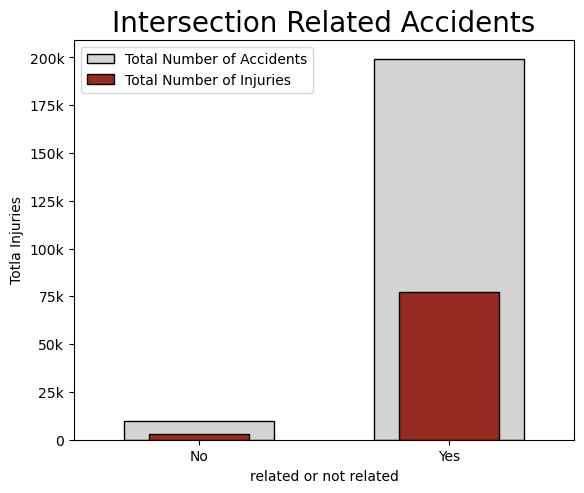

In [389]:
# Figure 3: bar chart  - Intersection related Accidents and injuries
intersection_inj = df.groupby('intersection_related_i')['injuries_total'].sum().reset_index(name='cnt')
intersection_accid = df.groupby('intersection_related_i')['intersection_related_i'].count().reset_index(name='cnt')

fig = plt.figure(figsize=(5,4))
ax = fig.add_axes([0,0,1,1])
sns.barplot(data=intersection_accid ,x=intersection_accid['intersection_related_i'], y=intersection_accid['cnt'], color='#D4D4D4' ,edgecolor='black', width=0.6, label='Total Number of Accidents')
sns.barplot(data=intersection_inj ,x=intersection_inj['intersection_related_i'], y=intersection_inj['cnt'], color='#A91B0D', edgecolor='black', width=0.4,  label='Total Number of Injuries')
ax.set_title('Intersection Related Accidents', fontsize=20)
ax.set_xlabel('related or not related')
ax.set_ylabel('Totla Injuries')
ax.set_xticklabels(['No','Yes'])
ax.set_yticks(np.arange(0,225000,25000))
ax.set_yticklabels(['0','25k','50k','75k','100k','125k','150k','175k','200k'])
plt.legend()
plt.show()

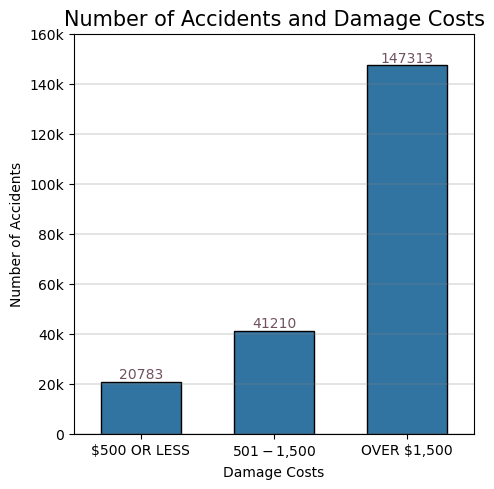

In [391]:
# Figure 4 : bar chart  - damage 
d = df.groupby('damage')['damage'].count().reset_index(name='damageCNT')
fig = plt.figure(figsize=(4,4))
ax = fig.add_axes([0,0,1,1,])
sns.barplot(data=d, x=d['damage'], y=d['damageCNT'], edgecolor='black', width=0.6)
ax.set_title('Number of Accidents and Damage Costs', fontsize=15)
ax.set_xlabel('Damage Costs')
ax.set_ylabel('Number of Accidents')
ax.set_yticks(np.arange(0,180000,20000))
ax.set_yticklabels(['0','20k','40k','60k','80k','100k','120k','140k','160k'])

ax.text(0,20783,'20783',ha='center', va='bottom', color='#705160')
ax.text(1,41210,'41210',ha='center', va='bottom', color='#705160')
ax.text(2,147313,'147313',ha='center', va='bottom', color='#705160')

plt.grid(axis='y', color = 'gray', linewidth = 0.3)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_10588\2734941450.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(['','','',''])
C:\Users\HP\AppData\Local\Temp\ipykernel_10588\2734941450.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(['','','','',''])
C:\Users\HP\AppData\Local\Temp\ipykernel_10588\2734941450.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels(['','','','','',''])
C:\Users\HP\AppData\Local\Temp\ipykernel_10588\2734941450.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_yticklabels(['','','','','',''])
C:\Users\HP\AppData\Local\Temp\ipykernel_10588\2734941450.py:73: U

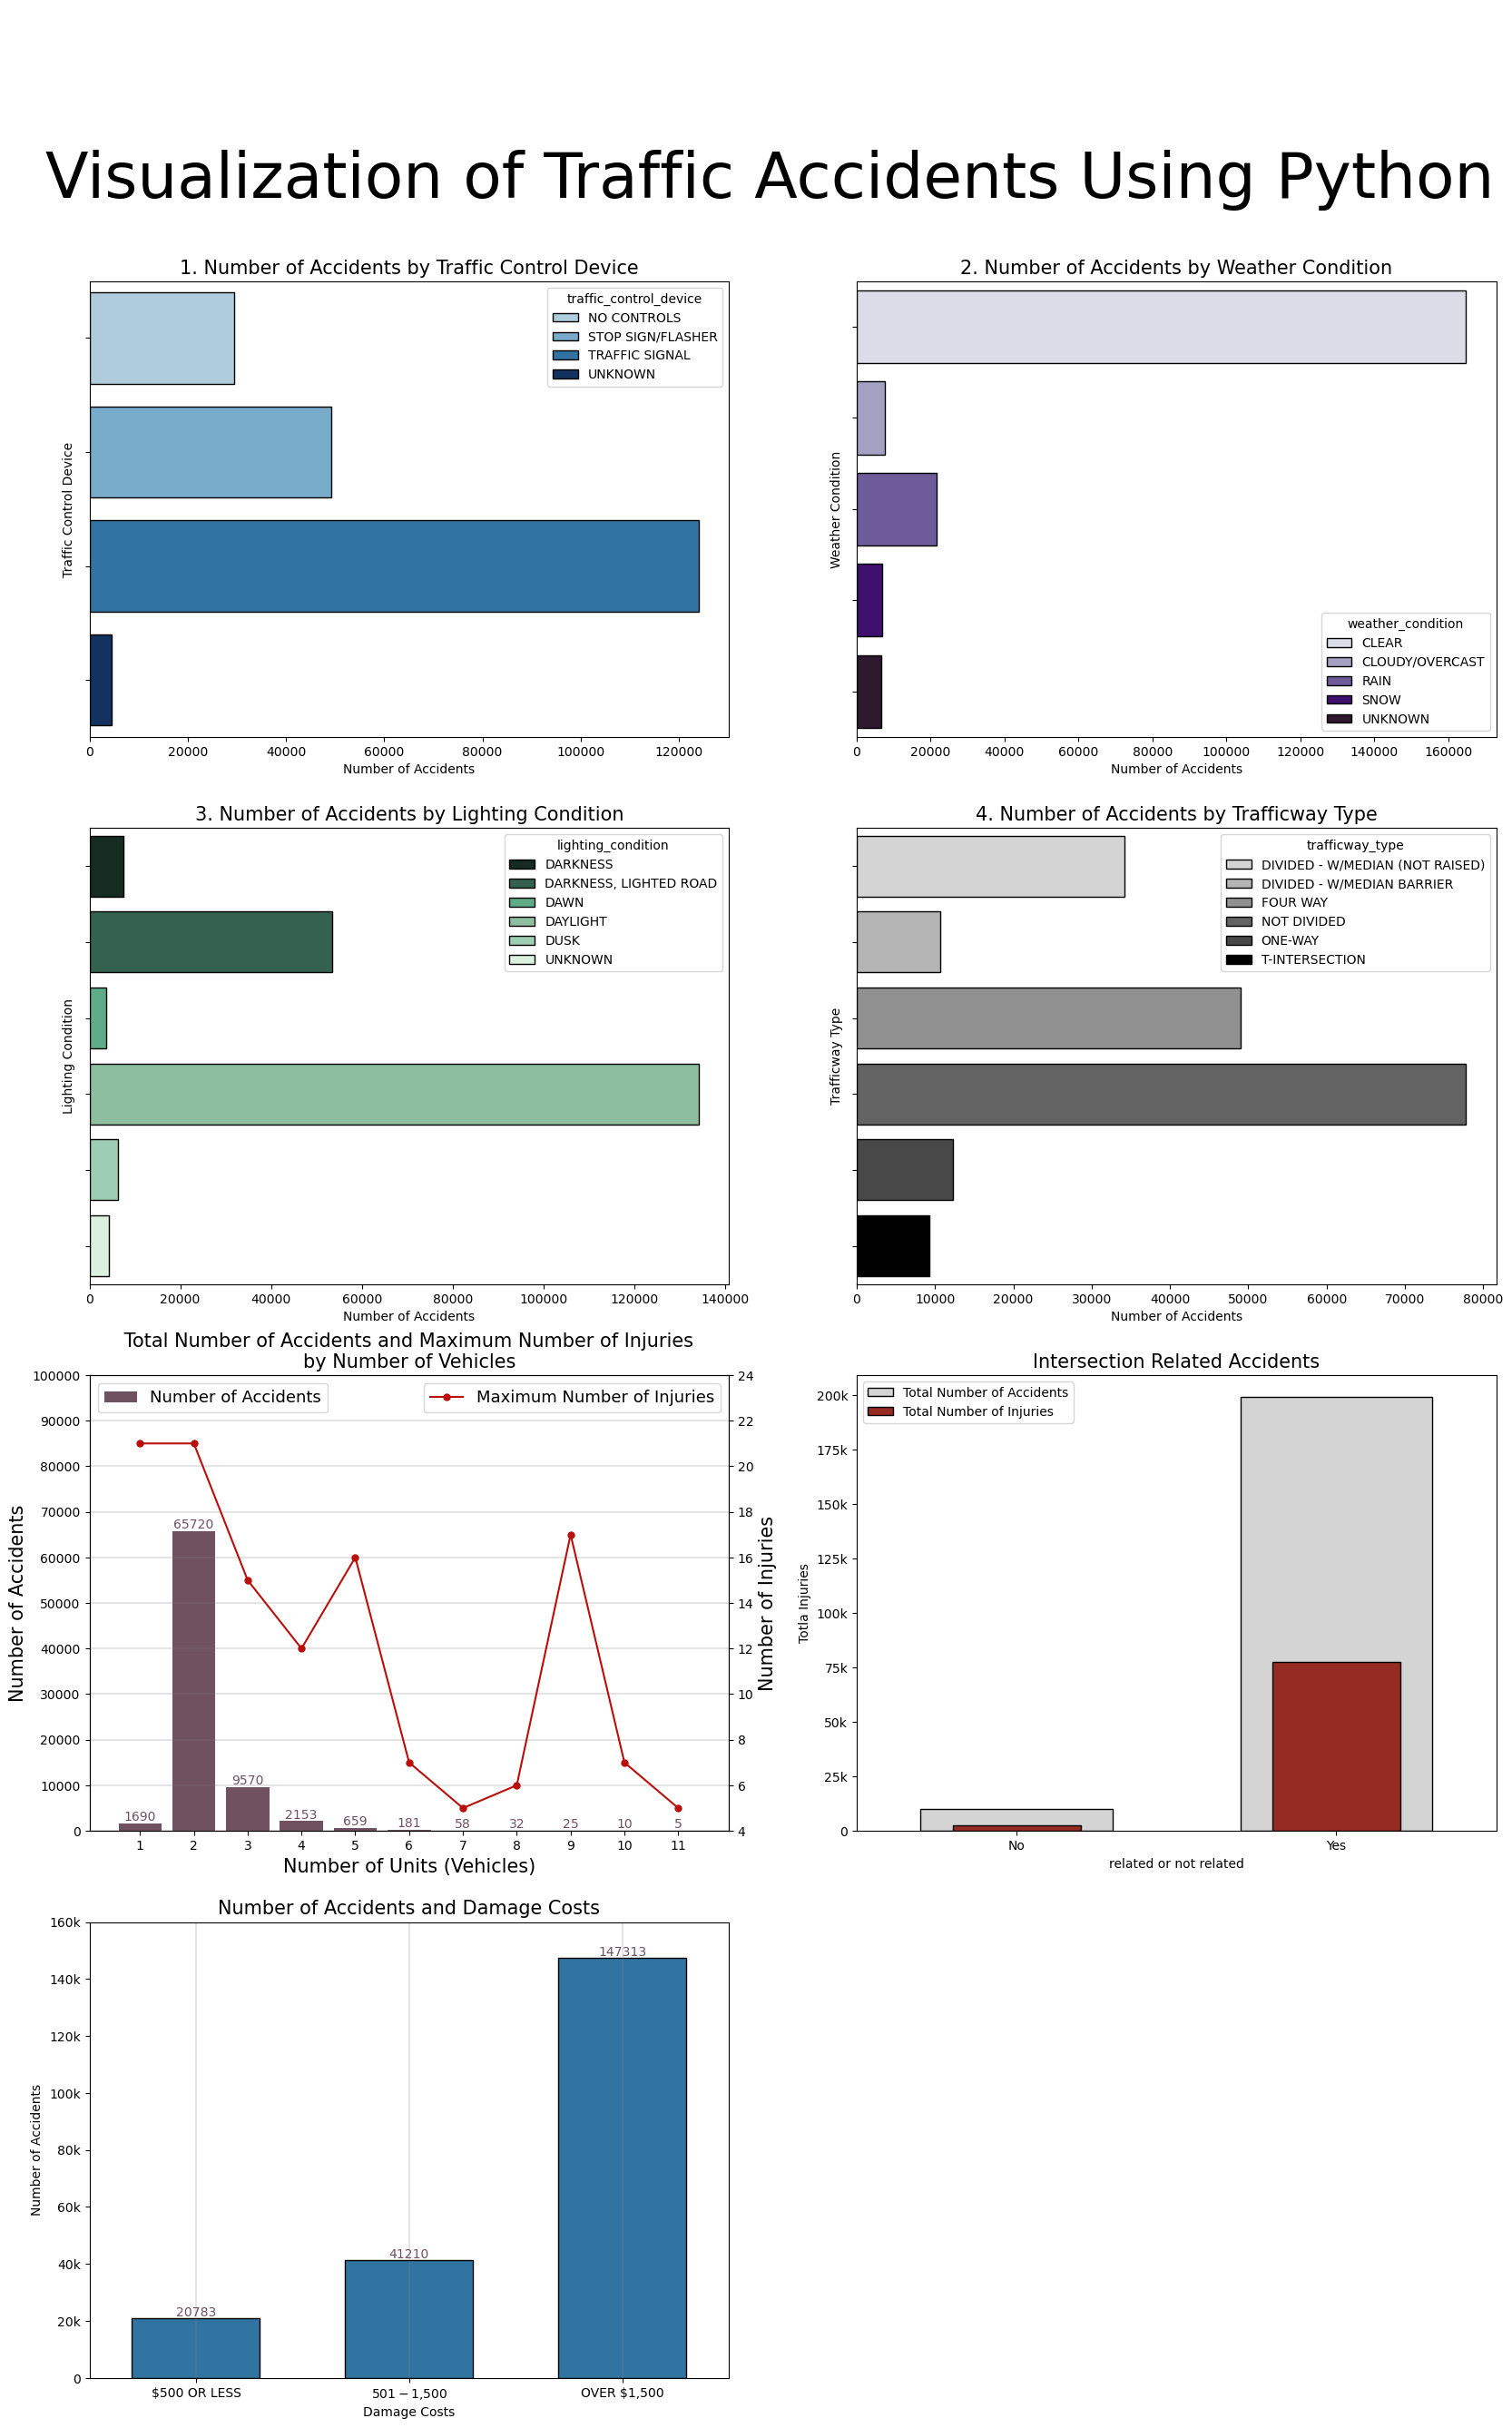

In [393]:
# DASHBOARD

fig = fig = plt.figure(figsize=(20,30))
ax1 = fig.add_subplot(421)
sns.barplot(data=device, y='traffic_control_device', x='cnt', hue='traffic_control_device', palette=c, edgecolor='black', legend=True)
ax1.set_title('1. Number of Accidents by Traffic Control Device', fontsize=15)
ax1.set_xlabel('Number of Accidents')
ax1.set_ylabel('Traffic Control Device')
ax1.set_yticklabels(['','','',''])


ax2 = fig.add_subplot(422)
sns.barplot(data=weather, y='weather_condition', x='cnt', hue='weather_condition', palette=c1, edgecolor='black', legend=True)
ax2.set_title('2. Number of Accidents by Weather Condition', fontsize=15)
ax2.set_xlabel('Number of Accidents')
ax2.set_ylabel('Weather Condition')
ax2.set_yticklabels(['','','','',''])

ax3 = fig.add_subplot(423)
sns.barplot(data=lighting, y='lighting_condition', x='cnt', hue='lighting_condition', palette=c2, edgecolor='black', legend=True)
ax3.set_title('3. Number of Accidents by Lighting Condition', fontsize=15)
ax3.set_xlabel('Number of Accidents')
ax3.set_ylabel('Lighting Condition')
ax3.set_yticklabels(['','','','','',''])

ax4 = fig.add_subplot(424)
sns.barplot(data=trafficway, y='trafficway_type', x='cnt', hue='trafficway_type', palette=c3, edgecolor='black', legend=True)
ax4.set_title('4. Number of Accidents by Trafficway Type', fontsize=15)
ax4.set_xlabel('Number of Accidents')
ax4.set_ylabel('Trafficway Type')
ax4.set_yticklabels(['','','','','',''])


ax5 = plt.subplot(425)
ax5.bar(data1['num_units'], data1['cnt'], color='#705160', label='Number of Accidents')
ax5.set_xlabel('Number of Units (Vehicles)', fontsize=15)
ax5.set_ylabel('Number of Accidents', fontsize=15)
ax5.tick_params(axis = 'y')
ax5.set_xticks(np.arange(1,12,1))
ax5.set_yticks(np.arange(0,110000,10000))
ax5.legend(loc='upper left', fontsize = 13)

## To write the exact number of crashes 
ax5.text(1, 1690, '1690', ha='center', va='bottom', color='#705160')
ax5.text(2, 65720, '65720', ha='center', va='bottom', color='#705160')
ax5.text(3, 9570, '9570', ha='center', va='bottom', color='#705160')
ax5.text(4, 2153, '2153', ha='center', va='bottom', color='#705160')
ax5.text(5, 659, '659', ha='center', va='bottom', color='#705160')
ax5.text(6, 200, '181', ha='center', va='bottom', color='#705160')
ax5.text(7, 100, '58', ha='center', va='bottom', color='#705160')
ax5.text(8, 100, '32', ha='center', va='bottom', color='#705160')
ax5.text(9, 100, '25', ha='center', va='bottom', color='#705160')
ax5.text(10, 100, '10', ha='center', va='bottom', color='#705160')
ax5.text(11, 100, '5', ha='center', va='bottom', color='#705160')


ax55 = ax5.twinx()
ax55.plot(data1['num_units'],data1['MAX'], color = '#B90E0A', marker='o', markersize=5, label ='Maximum Number of Injuries')
ax55.set_ylabel('Number of Injuries', fontsize=15)
ax55.tick_params(axis = 'y')
ax55.set_yticks(np.arange(4,25,2))
ax55.legend(loc='upper right', fontsize = 13)
plt.grid(color = 'gray', linewidth = 0.3)
plt.title(' Total Number of Accidents and Maximum Number of Injuries \nby Number of Vehicles', fontsize=15)


ax6 = plt.subplot(426)
sns.barplot(data=intersection_accid ,x=intersection_accid['intersection_related_i'], y=intersection_accid['cnt'], color='#D4D4D4' ,edgecolor='black', width=0.6, label='Total Number of Accidents')
sns.barplot(data=intersection_inj ,x=intersection_inj['intersection_related_i'], y=intersection_inj['cnt'], color='#A91B0D', edgecolor='black', width=0.4,  label='Total Number of Injuries')
ax6.set_title('Intersection Related Accidents', fontsize=15)
ax6.set_xlabel('related or not related')
ax6.set_ylabel('Totla Injuries')
ax6.set_xticklabels(['No','Yes'])
ax6.set_yticks(np.arange(0,225000,25000))
ax6.set_yticklabels(['0','25k','50k','75k','100k','125k','150k','175k','200k'])
ax6.legend()

ax7 = plt.subplot(427)
sns.barplot(data=d, x=d['damage'], y=d['damageCNT'], edgecolor='black', width=0.6)
ax7.set_title('Number of Accidents and Damage Costs', fontsize=15)
ax7.set_xlabel('Damage Costs')
ax7.set_ylabel('Number of Accidents')
ax7.set_yticks(np.arange(0,180000,20000))
ax7.set_yticklabels(['0','20k','40k','60k','80k','100k','120k','140k','160k'])

ax7.text(0,20783,'20783',ha='center', va='bottom', color='#705160')
ax7.text(1,41210,'41210',ha='center', va='bottom', color='#705160')
ax7.text(2,147313,'147313',ha='center', va='bottom', color='#705160')


plt.suptitle('\n\nVisualization of Traffic Accidents Using Python', fontsize=50)

plt.grid(axis='x', color = 'gray', linewidth = 0.3)
plt.show()